### Homography + Difference Detection

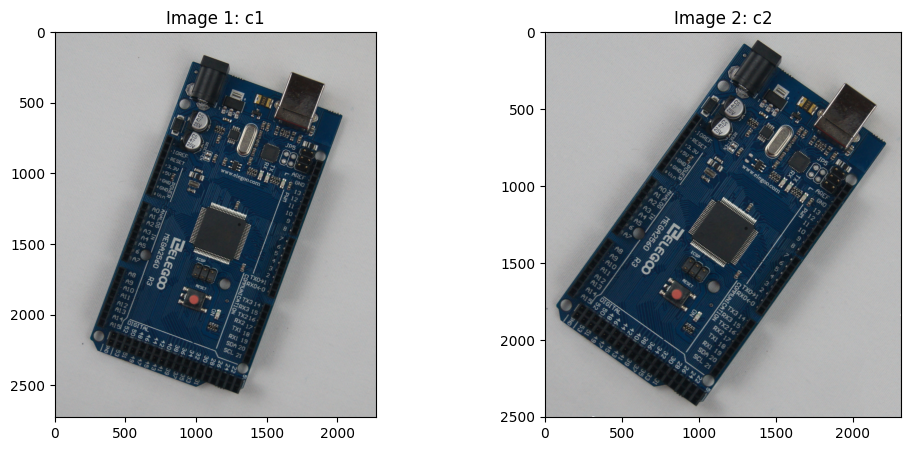

In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

im1 = cv.imread("c1.jpg")
im2 = cv.imread("c2.jpg")

im1_rgb = cv.cvtColor(im1, cv.COLOR_BGR2RGB)
im2_rgb = cv.cvtColor(im2, cv.COLOR_BGR2RGB)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(im1_rgb)
plt.title("Image 1: c1")
plt.axis("on")

plt.subplot(1,2,2)
plt.imshow(im2_rgb)
plt.title("Image 2: c2")
plt.axis("on")
plt.show()

### 3-(a) Manual Homography

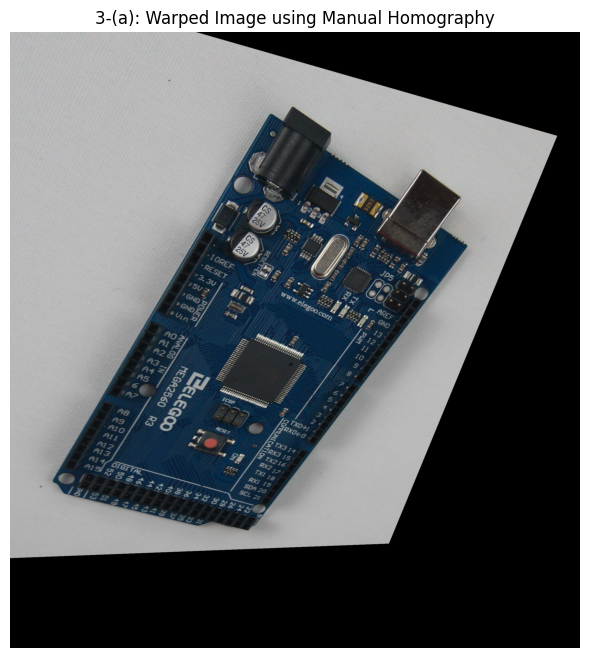

Manual Homography Matrix:
[[ 1.49039993e+00  1.63237419e-02 -1.29795187e+02]
 [ 3.83533349e-01  1.41185559e+00 -2.53944138e+02]
 [ 2.06216173e-04  2.49929091e-04  1.00000000e+00]]


In [3]:
# Manually selected corresponding points
# Replace these values if your image size is different

p1 = np.float32([
    [300, 80],
    [720, 160],
    [650, 980],
    [170, 870],
    [455, 520],
    [370, 720]
])

p2 = np.float32([
    [360, 70],
    [760, 180],
    [620, 1000],
    [110, 830],
    [455, 535],
    [345, 720]
])

# Compute homography
H_manual, mask_manual = cv.findHomography(p1, p2, cv.RANSAC)

# Warp image 1 to image 2 perspective
height, width = im2.shape[:2]
warped_manual = cv.warpPerspective(im1, H_manual, (width, height))

warped_manual_rgb = cv.cvtColor(warped_manual, cv.COLOR_BGR2RGB)

plt.figure(figsize=(8,8))
plt.imshow(warped_manual_rgb)
plt.title("3-(a): Warped Image using Manual Homography")
plt.axis("off")
plt.show()

print("Manual Homography Matrix:")
print(H_manual)

### 3-(b) Difference Image

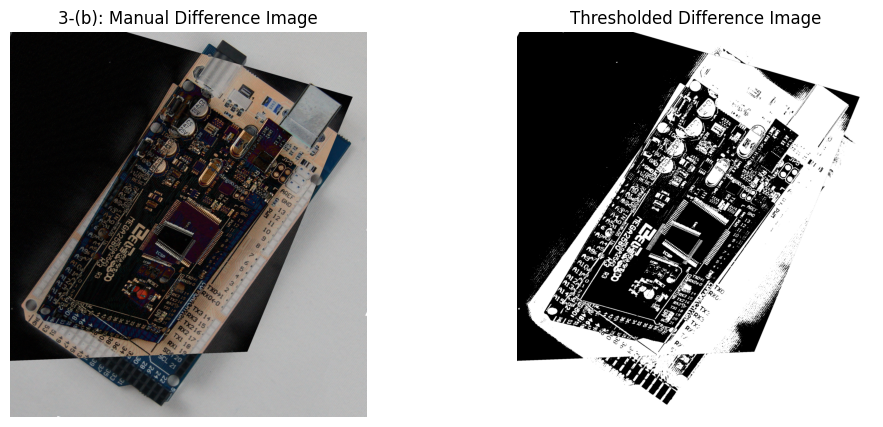

In [4]:
# Difference between warped image and target image
diff_manual = cv.absdiff(warped_manual, im2)

# Convert to grayscale and threshold for clearer difference
gray_diff_manual = cv.cvtColor(diff_manual, cv.COLOR_BGR2GRAY)
_, thresh_manual = cv.threshold(gray_diff_manual, 30, 255, cv.THRESH_BINARY)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(cv.cvtColor(diff_manual, cv.COLOR_BGR2RGB))
plt.title("3-(b): Manual Difference Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(thresh_manual, cmap="gray")
plt.title("Thresholded Difference Image")
plt.axis("off")

plt.show()

### 3-(c) ORB Feature Matching

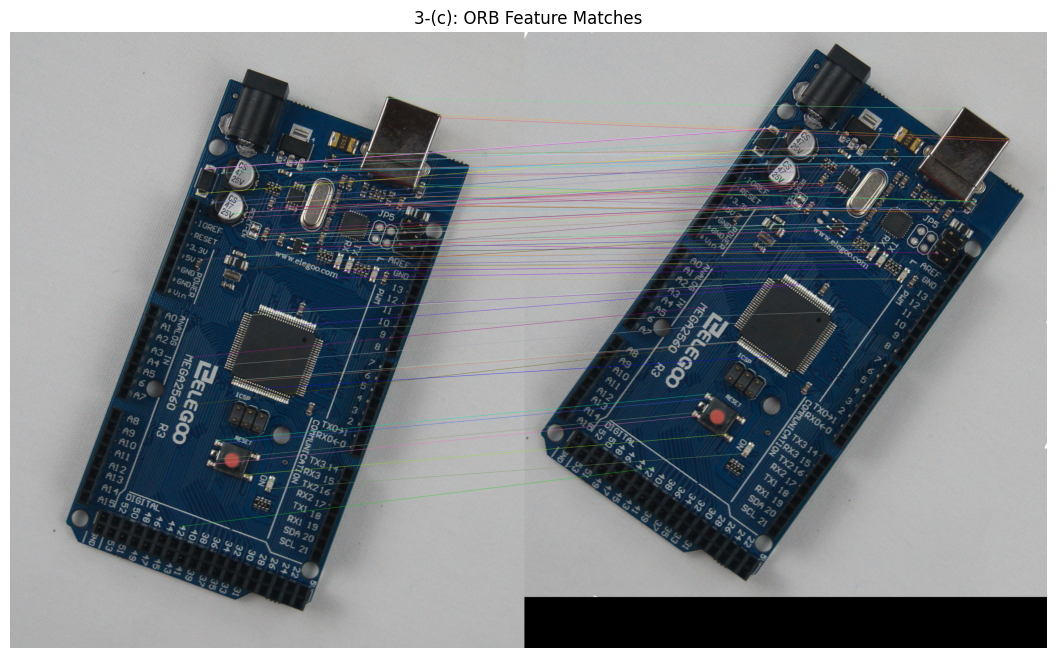

Number of keypoints in image 1: 3000
Number of keypoints in image 2: 3000
Number of matches: 2182


In [5]:
# Convert images to grayscale
gray1 = cv.cvtColor(im1, cv.COLOR_BGR2GRAY)
gray2 = cv.cvtColor(im2, cv.COLOR_BGR2GRAY)

# ORB detector
orb = cv.ORB_create(nfeatures=3000)

kp1, des1 = orb.detectAndCompute(gray1, None)
kp2, des2 = orb.detectAndCompute(gray2, None)

# Brute Force Matcher
bf = cv.BFMatcher(cv.NORM_HAMMING, crossCheck=True)
matches = bf.match(des1, des2)

# Sort matches by distance
matches = sorted(matches, key=lambda x: x.distance)

# Draw best matches
best_matches = matches[:80]

match_img = cv.drawMatches(
    im1, kp1,
    im2, kp2,
    best_matches,
    None,
    flags=cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.figure(figsize=(16,8))
plt.imshow(cv.cvtColor(match_img, cv.COLOR_BGR2RGB))
plt.title("3-(c): ORB Feature Matches")
plt.axis("off")
plt.show()

print("Number of keypoints in image 1:", len(kp1))
print("Number of keypoints in image 2:", len(kp2))
print("Number of matches:", len(matches))

### 3-(d) Homography Using ORB Matches

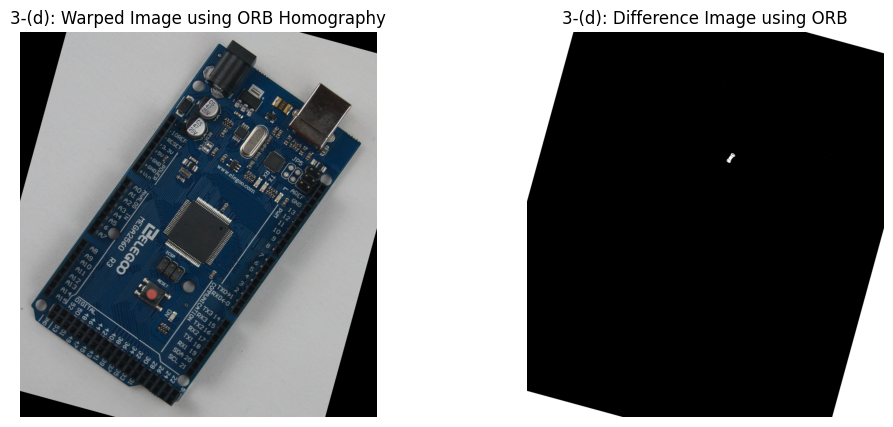

Automatic Homography Matrix:
[[ 9.64352400e-01 -2.63671308e-01  4.05947432e+02]
 [ 2.63926361e-01  9.64285398e-01 -3.84033163e+02]
 [-6.25454997e-08 -2.10951814e-08  1.00000000e+00]]


In [6]:
# Extract matched points
src_pts = np.float32([kp1[m.queryIdx].pt for m in matches]).reshape(-1, 1, 2)
dst_pts = np.float32([kp2[m.trainIdx].pt for m in matches]).reshape(-1, 1, 2)

# Compute homography using RANSAC
H_auto, mask_auto = cv.findHomography(src_pts, dst_pts, cv.RANSAC, 5.0)

# Warp image
warped_auto = cv.warpPerspective(im1, H_auto, (width, height))

# Difference image
diff_auto = cv.absdiff(warped_auto, im2)

gray_diff_auto = cv.cvtColor(diff_auto, cv.COLOR_BGR2GRAY)
_, thresh_auto = cv.threshold(gray_diff_auto, 30, 255, cv.THRESH_BINARY)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(cv.cvtColor(warped_auto, cv.COLOR_BGR2RGB))
plt.title("3-(d): Warped Image using ORB Homography")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(thresh_auto, cmap="gray")
plt.title("3-(d): Difference Image using ORB")
plt.axis("off")

plt.show()

print("Automatic Homography Matrix:")
print(H_auto)